# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

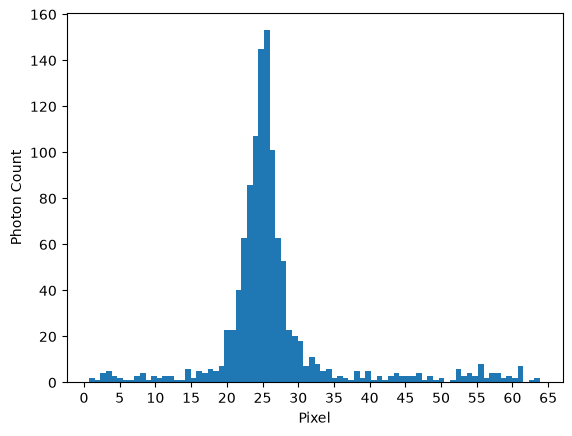

The star is located at 26.63 ± 0.26


In [130]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

data = np.genfromtxt(f'../../labs/02/data/saumyap2.csv', delimiter=',', names=True)
x = data['x']
n = len(x)

plt.hist(x, 80)
plt.xlabel('Pixel')
plt.ylabel('Photon Count')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(5))   # tick every 1 unit
plt.show()

mean = np.mean(x)
std = np.std(x, ddof=1)
sigma = std/np.sqrt(n)
print(f"The star is located at {mean:.2f} ± {sigma:.2f}")

**ANSWER (a few sentences):**

Yes the estimator is biased to the right. The peak is close to x=25, though the mean is 26.63, showing that the outliers are biasing the estimator. The mean averages all the photons, including background and the size of the bias is dependent on the background fraction and the spread of the noise away from the star position. I chose this bin size such that its large enough to show the peak at the stars location but not too large to the point where there's too much noise.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [131]:
# Part 2: your work here
median = np.median(x)
print(f"Median: {median:.3f}")
print('The median is only mildly biased for this dataset due to the background. The magnitude of this bias depends on the background fraction and the location of the source relative to the center of the detector. I will estimate the variance of the median empirically in Part 3.')
def sigma_clip(x,k=3, max_iter=10):
    mask = np.ones(len(x), dtype=bool)
    for i in range(max_iter):
        center = np.median(x[mask])
        MAD = np.median(np.abs(x[mask] - center))
        sig = 1.4826 * MAD

        new_mask = np.abs(x - center) < k * sig
        if np.array_equal(new_mask, mask):
            print(f"Converged after {i+1} iterations")
            break
        mask = new_mask
        
    x_kept = x[mask]
    mean = np.mean(x_kept)
    sigma_mean = np.std(x_kept, ddof=1) / np.sqrt(len(x_kept))
    print(f"Clipped mean: {mean:.2f} ± {sigma_mean:.2f}  ({len(x_kept)}/{len(x)} photons kept)")
    return mean, sigma_mean, mask

mean_clip, sigma_clip_val, mask = sigma_clip(x)

print("I used iterative 3sigma clipping, with the median as the center and 1.482 MAD as a robust estimate of the standard deviation. I chose 3 as my threshold since 99.73% of the mass lies in this range in a Gaussian this this keeps almost all of the starlight without including extreme outliers.")
print ("Using the median and MAD for the clipping step makes the initial estimate less sensitive to the background than using the mean and standard deviation.")

Median: 25.219
The median is only mildly biased for this dataset due to the background. The magnitude of this bias depends on the background fraction and the location of the source relative to the center of the detector. I will estimate the variance of the median empirically in Part 3.
Converged after 5 iterations
Clipped mean: 24.98 ± 0.07  (930/1134 photons kept)
I used iterative 3sigma clipping, with the median as the center and 1.482 MAD as a robust estimate of the standard deviation. I chose 3 as my threshold since 99.73% of the mass lies in this range in a Gaussian this this keeps almost all of the starlight without including extreme outliers.
Using the median and MAD for the clipping step makes the initial estimate less sensitive to the background than using the mean and standard deviation.


In [132]:
from scipy.optimize import minimize
from scipy.special import gamma
from scipy.optimize._numdiff import approx_derivative

beta = 2.5
r0 = 4.0
W = 64.0  

norm = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def moffat(x, x0):
    return norm * (1.0 + ((x - x0) / r0)**2)**(-beta)

def neg_log_like(theta, x):
    x0, f_bg = theta
    p = f_bg / 64.0 + (1 - f_bg) * moffat(x, x0)
    return -np.sum(np.log(p))

res = minimize(neg_log_like, [np.median(x), 0.3], args=(x,),
               method='L-BFGS-B', bounds=[(0.0, 64.0), (0.0, 1.0)])

x0_hat, f_bg_hat = res.x
print(f"x0   = {x0_hat:.3f}  px")
print(f"f_bg = {f_bg_hat:.3f}")

def gradient(theta):
    return approx_derivative(
        lambda t: np.array([neg_log_like(t, x)]),
        theta
    ).ravel()

hessian = approx_derivative(gradient, res.x)

cov = np.linalg.inv(hessian)

sigma_x0, sigma_fbg = np.sqrt(np.diag(cov))

print(f"sigma_x0   = {sigma_x0:.3f}  px")
print(f"sigma_f_bg = {sigma_fbg:.3f}")

x0   = 24.995  px
f_bg = 0.185
sigma_x0   = 0.081  px
sigma_f_bg = 0.014


In [133]:
from scipy.integrate import quad

C = gamma(beta) / (r0*np.sqrt(np.pi)*gamma(beta - 0.5))

def M(x, x0):
    u = (x - x0)/r0
    return C * (1.0 + u**2)**(-beta)

def p(x, x0, f):
    return f/W + (1.0 - f)*M(x, x0)

def dp_dx0(x, x0, f):
    u = (x - x0)/r0
    dM = C * (2.0*beta/r0) * u * (1.0 + u**2)**(-beta - 1)
    return (1.0 - f)*dM

def dp_df(x, x0, f):
    return 1.0/W - M(x, x0)

x0m, fm = x0_hat, f_bg_hat

I = np.zeros((2,2))
grads = [dp_dx0, dp_df]
for a in range(2):
    for b in range(2):
        I[a,b], _ = quad(lambda x: grads[a](x,x0m,fm)*grads[b](x,x0m,fm)/p(x,x0m,fm),
                         0.0, W, limit=500)

F = len(x) * I
cov = np.linalg.inv(F)
sigma_crb = np.sqrt(cov[0,0])
I_marginal = I[0,0] - I[0,1]**2 / I[1,1]    

print(f"per-photon I11 naive = {I[0,0]:.4f}")
print(f"per-photon I11 marginal = {I_marginal:.4f}")
print(f"CRB sigma_x0 = {sigma_crb:.3f} px   (N = {len(x)})")
print(f"if you used 1/sqrt(N*I11) alone you'd get {1/np.sqrt(len(x)*I[0,0]):.3f}")

per-photon I11 naive = 0.1333
per-photon I11 marginal = 0.1333
CRB sigma_x0 = 0.081 px   (N = 1134)
if you used 1/sqrt(N*I11) alone you'd get 0.081


I evaluated the Fisher matrix numerically over the detector window at the MLE values of \(x_0\) and \(f_{\rm bg}\), since the true parameters are unknown.

The naive mean exceeds 3xCRB. The sigma-clipped mean is smaller than the CRB which might makes sense since this is a biased estimator. MLE uncertainty is nearly equal to the CRB which would make it the best estimator. 

**FINAL ANSWER:** $x_0 = $ 24.995 $\pm$ 0.081 px , $f_{\rm bg} = $ 0.185 $\pm$ 0.014 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.081 px

**Justification and uncertainty method (a short paragraph):**

*your answer goes here*
THe MLE is the final answer because the Monte Carlo tests show that it was the best fit out of the estimators tested with its low bias and standard deviation that was close to the CRB. It also performed well on the Coverage test which shows it's uncertainty was well calibrated. THe uncertainty was estimated from the inverse of the observed information matrix which was obtained from the Hessian of the negative log-likelihood evaluated at the maximum. The resulting 0.081 uncertainty is within the limit because it its nearly equal to the CRB. 

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

I'll test the 4 estimators using a simulated dataset generated fro mthe same star model. for simulating: a 1-D Moffat with exponent $\beta$ is a Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by $r_0/\sqrt{\nu}$. I will generate the same number of photons as the actual dataset and randomly generate noise uniformly.

1. Closure test.
   I'll choose a known set of parameters for $x_0$ and $f_{bg}$ with $\beta=2.5$, $r_0=4$ px, and $N=1134$. Using this, I will generate a dataset and run them through the 4 estimators and compare their results with the true values.
2. Bias and efficiency.
   I will run a Monte Carlo simulation with many simulated datasets. For every simulated dataset I will calculate the sample mean, median, sigma-clipped mean, and MLE. I will measure the bias of each estimator from the mean recovered value minus the known $x_0$, and measure its sampling variance from the distribution of recovered values. Then I will compare the variances to the CRB and plot biases and the variances. 
4. Coverage.
   For each simulated dataset I will form the 68% intervals using the estimators reported $1 \sigma$ uncertainty and check whether $x_0$ falls within that range. This should be the case 68% percent of the time
6. Sensitivity.
   I will input slight perturbations for $\beta$ and $r_0$ and repeat the simulations. I will also make the fraction of photons falling outside the reflector window to be non-negligible and test the effects of that. I will compare the recovered $\hat{x}_0$ with the correctly specified model result.

CLOSURE TEST
Truth: x0 = 25.000, f_bg = 0.200
Mean:    26.301 ± 0.266
Median:  24.992
Clip:    24.864 ± 0.077
MLE:     24.865 ± 0.082
MLE f_bg = 0.192 ± 0.014
MONTE CARLO TEST
Estimator       Bias [px]    Variance [px²]    Std. dev. [px]
Mean             +1.4089       0.07691          0.2773
Median           +0.1425       0.00870          0.0933
Clipped mean     -0.0075       0.00735          0.0857
MLE              -0.0063       0.00628          0.0792

CRB sigma_x0 = 0.0823 px
CRB variance = 0.00678 px^2


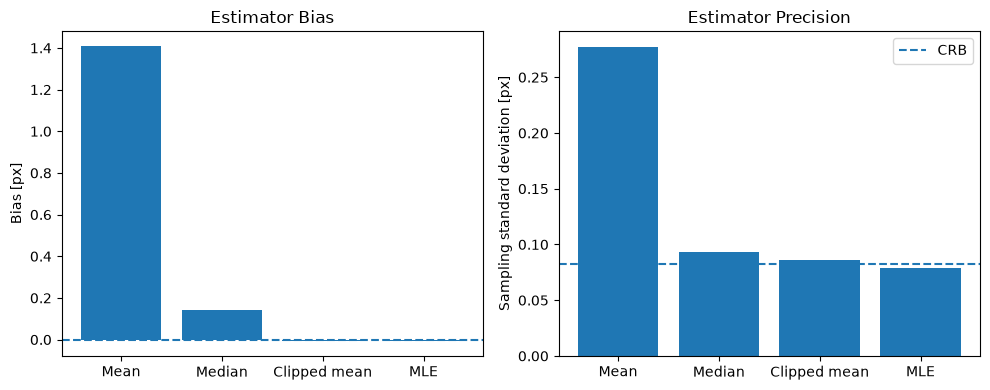

68% COVERAGE
Mean:          0.000
Median:        0.296
Clipped mean:  0.632
MLE:           0.684

Median empirical sigma = 0.0933 px

SENSITIVITY TO BETA
fit beta=2.3: mean x0=24.9992, bias=-0.0008
fit beta=2.5: mean x0=25.0101, bias=+0.0101
fit beta=2.7: mean x0=25.0041, bias=+0.0041

SENSITIVITY TO r0
fit r0=3.8: mean x0=25.0002, bias=+0.0002
fit r0=4.0: mean x0=24.9984, bias=-0.0016
fit r0=4.2: mean x0=25.0003, bias=+0.0003

EDGE / LOST-PHOTON TEST
Truth x0 = 4.0
Recovered mean x0 = 4.1965
Bias = +0.1965


In [134]:
# Part 3b: execute the plan here
beta = 2.5
r0 = 4.0
W = 64.0
N = len(x)

C = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def moffat(x, x0, beta=beta, r0=r0):
    C = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))
    return C * (1 + ((x - x0) / r0)**2)**(-beta)

def mixture_pdf(x, x0, f_bg, beta=beta, r0=r0):
    return f_bg / W + (1 - f_bg) * moffat(x, x0, beta, r0)

def sample_mean(x):
    mean = np.mean(x)
    std = np.std(x, ddof=1)
    sigma = std/np.sqrt(n)
    return mean, sigma

def median_estimator(x):
    return np.median(x)

def sigma_clip(x,k=3, max_iter=10):
    mask = np.ones(len(x), dtype=bool)
    for i in range(max_iter):
        center = np.median(x[mask])
        MAD = np.median(np.abs(x[mask] - center))
        sig = 1.4826 * MAD

        new_mask = np.abs(x - center) < k * sig
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
        
    x_kept = x[mask]
    mean = np.mean(x_kept)
    sigma_mean = np.std(x_kept, ddof=1) / np.sqrt(len(x_kept))
    return mean, sigma_mean
    
def neg_log_like(theta, x, beta_fit=beta, r0_fit=r0):
    x0, f_bg = theta
    p = mixture_pdf(x, x0, f_bg, beta_fit, r0_fit)

    if np.any(p <= 0):
        return np.inf

    return -np.sum(np.log(p))
def mle_estimator(x, beta_fit=beta, r0_fit=r0):

    res = minimize(
        neg_log_like,
        [np.median(x), 0.2],
        args=(x, beta_fit, r0_fit),
        method="L-BFGS-B",
        bounds=[(0, W), (0, 1)]
    )

    x0_hat, f_hat = res.x

    def gradient(theta):
        return approx_derivative(
            lambda t: np.array([neg_log_like(t, x, beta_fit, r0_fit)]),
            theta
        ).ravel()

    H = approx_derivative(gradient, res.x)
    cov = np.linalg.inv(H)

    sig_x0 = np.sqrt(cov[0, 0])
    sig_f = np.sqrt(cov[1, 1])

    return x0_hat, sig_x0, f_hat, sig_f

# Simulation

rng = np.random.default_rng(457)

def simulate_dataset(x0_true, f_true, N=N, beta_true=beta, r0_true=r0):

    is_bg = rng.random(N) < f_true
    n_bg = np.sum(is_bg)

    x_sim = np.empty(N)
    x_sim[is_bg] = rng.uniform(0, W, n_bg)

    # Moffat = Student-t with nu = 2 beta - 1
    nu = 2 * beta_true - 1
    scale = r0_true / np.sqrt(nu)

    x_sim[~is_bg] = (
        x0_true
        + scale * rng.standard_t(nu, size=np.sum(~is_bg))
    )

    x_sim = x_sim[(x_sim >= 0) & (x_sim <= W)]

    return x_sim

# Closure

x0_true = 25
f_true = 0.20

x_closure = simulate_dataset(x0_true, f_true)

mean_c, mean_sig_c = sample_mean(x_closure)
med_c = median_estimator(x_closure)
clip_c, clip_sig_c = sigma_clip(x_closure)
mle_c, mle_sig_c, f_mle_c, f_sig_c = mle_estimator(x_closure)

print("CLOSURE TEST")
print(f"Truth: x0 = {x0_true:.3f}, f_bg = {f_true:.3f}")
print(f"Mean:    {mean_c:.3f} ± {mean_sig_c:.3f}")
print(f"Median:  {med_c:.3f}")
print(f"Clip:    {clip_c:.3f} ± {clip_sig_c:.3f}")
print(f"MLE:     {mle_c:.3f} ± {mle_sig_c:.3f}")
print(f"MLE f_bg = {f_mle_c:.3f} ± {f_sig_c:.3f}")


# Bias

n_sim = 1000

results = {
    "Mean": [],
    "Median": [],
    "Clipped mean": [],
    "MLE": []
}
    
for _ in range(n_sim):
    xs = simulate_dataset(x0_true, f_true)

    results["Mean"].append(sample_mean(xs)[0])
    results["Median"].append(median_estimator(xs))
    results["Clipped mean"].append(sigma_clip(xs)[0])
    results["MLE"].append(mle_estimator(xs)[0])

print("MONTE CARLO TEST")
print("Estimator       Bias [px]    Variance [px²]    Std. dev. [px]")

for name, vals in results.items():
    vals = np.array(vals)
    bias = np.mean(vals) - x0_true
    variance = np.var(vals, ddof=1)
    print(f"{name:<16} {bias:+.4f}       {variance:.5f}          {np.std(vals, ddof=1):.4f}")

I = np.zeros((2, 2))
grads = [dp_dx0, dp_df]

for a in range(2):
    for b in range(2):
        I[a, b], _ = quad(
            lambda z: grads[a](z, x0_true, f_true)
                    * grads[b](z, x0_true, f_true)
                    / p(z, x0_true, f_true),
            0, W
        )

crb = np.sqrt(np.linalg.inv(N * I)[0, 0])

print(f"\nCRB sigma_x0 = {crb:.4f} px")
print(f"CRB variance = {crb**2:.5f} px^2")

# Bias and variance figure

names = list(results.keys())
bias = [np.mean(results[n]) - x0_true for n in names]
std = [np.std(results[n], ddof=1) for n in names]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(names, bias)
ax[0].axhline(0, ls="--")
ax[0].set_ylabel("Bias [px]")
ax[0].set_title("Estimator Bias")

ax[1].bar(names, std)
ax[1].axhline(crb, ls="--", label="CRB")
ax[1].set_ylabel("Sampling standard deviation [px]")
ax[1].set_title("Estimator Precision")
ax[1].legend()

plt.tight_layout()
plt.show()

# Coverage

median_sigma = np.std(results["Median"], ddof=1)

mean_vals, mean_errs = [], []
clip_vals, clip_errs = [], []
mle_vals, mle_errs = [], []

for _ in range(n_sim):
    xs = simulate_dataset(x0_true, f_true)

    m, m_err = sample_mean(xs)
    c, c_err = sigma_clip(xs)
    xm, xm_err, _, _ = mle_estimator(xs)

    mean_vals.append(m)
    mean_errs.append(m_err)

    clip_vals.append(c)
    clip_errs.append(c_err)

    mle_vals.append(xm)
    mle_errs.append(xm_err)

# Convert to arrays
mean_vals, mean_errs = np.array(mean_vals), np.array(mean_errs)
clip_vals, clip_errs = np.array(clip_vals), np.array(clip_errs)
mle_vals, mle_errs = np.array(mle_vals), np.array(mle_errs)

# Fraction of 1-sigma intervals containing the true x0
coverage_mean = np.mean(np.abs(mean_vals - x0_true) <= mean_errs)
coverage_median = np.mean(
    np.abs(np.array(results["Median"]) - x0_true) <= median_sigma
)
coverage_clip = np.mean(np.abs(clip_vals - x0_true) <= clip_errs)
coverage_mle = np.mean(np.abs(mle_vals - x0_true) <= mle_errs)

print("68% COVERAGE")
print(f"Mean:          {coverage_mean:.3f}")
print(f"Median:        {coverage_median:.3f}")
print(f"Clipped mean:  {coverage_clip:.3f}")
print(f"MLE:           {coverage_mle:.3f}")
print(f"\nMedian empirical sigma = {median_sigma:.4f} px")


# Sensitivity

n_sens = 300

beta_tests = [2.3, 2.5, 2.7]
r0_tests = [3.8, 4.0, 4.2]

print("\nSENSITIVITY TO BETA")

for beta_fit in beta_tests:

    vals = []

    for i in range(n_sens):
        xs = simulate_dataset(x0_true, f_true, beta_true=2.5, r0_true=4.0)
        vals.append(mle_estimator(xs, beta_fit=beta_fit, r0_fit=4.0)[0])

    vals = np.array(vals)

    print(
        f"fit beta={beta_fit:.1f}: "
        f"mean x0={np.mean(vals):.4f}, "
        f"bias={np.mean(vals)-x0_true:+.4f}"
    )


print("\nSENSITIVITY TO r0")

for r0_fit in r0_tests:

    vals = []

    for i in range(n_sens):
        xs = simulate_dataset(x0_true, f_true, beta_true=2.5, r0_true=4.0)
        vals.append(mle_estimator(xs, beta_fit=2.5, r0_fit=r0_fit)[0])

    vals = np.array(vals)

    print(
        f"fit r0={r0_fit:.1f}: "
        f"mean x0={np.mean(vals):.4f}, "
        f"bias={np.mean(vals)-x0_true:+.4f}"
    )

print("\nEDGE / LOST-PHOTON TEST")

x0_edge = 4.0

vals = []

for i in range(n_sens):

    xs = simulate_dataset(x0_edge, f_true)

    vals.append(mle_estimator(xs)[0])

vals = np.array(vals)

print(f"Truth x0 = {x0_edge:.1f}")
print(f"Recovered mean x0 = {np.mean(vals):.4f}")
print(f"Bias = {np.mean(vals)-x0_edge:+.4f}")

**WHAT THE CHECKS FOUND:**

*your report goes here*

1. Closure


   Estimates:

Mean:    26.301 ± 0.266

Median:  24.992

Clip:    24.864 ± 0.077

MLE:     24.865 ± 0.082

MLE f_bg = 0.192 ± 0.014

This showed that the MLE and sigma-clipped estimators recover the true values decently well while the naive mean is shifter by the background

2. Bias and efficiency

   I measured the bias and variances of all 4 estimators through 1000 iterations

Outcomes:

Estimator       Bias [px]    Variance [px²]    Std. dev. [px]

Mean             +1.4089       0.07691          0.2773

Median           +0.1425       0.00870          0.0933

Clipped mean     -0.0075       0.00735          0.0857

MLE              -0.0063       0.00628          0.0792

Sample mean has a large bias and variance while the median's are smaller but still large compared to the CRB. The MLE standard deviation is slightly below the CRB. THis could be due to the small bias also seen through this test and Monte Carlo sample uncertainty. 

3. Coverage

   68% COVERAGE
   
Mean:          0.000

Median:        0.296

Clipped mean:  0.632

MLE:           0.684

The mean and median estimators fail this test because of their biases. The sigma-clipped mean also under-covered somewhat, showing that its standard error estimate is slightly too small. The MLE's coerage was only 0.004 off the 68% supporting its uncertainty.

4. Sensitivity
   Changing $\beta$ and $r_0$ with the MLE fit only led to very small changes in the resulting $x_0$ as they were all smaller than the unvertainty. The model has low sensitivity.
   Additionally, in the edge-test, I move the source to $x_0 = 4$ px and obtained a mean of $4.1965$ px. This shows a bias much larger than the ~0.08 px uncertainty showing high bias when the lost-photon fraction isn't negligible. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*your answer goes here*
ChatGPT, EcoGPT
Prompts:

- 

- Take the mle estimator and turn it into a function

- Write print statements for all these variables (in closure test)

- Used ai to help code the tests

- Used it to figure out how to find the uncertainties in the mixture model

- Check my results and help identify anything that needs further testing or explanation.


What it got wrong:

- AI initially treated the MLE result being slightly below the CRB as simply being “close to the Fisher limit.” I knew the meaning of the CRB and recognized that the standard bound applies to unbiased estimators. The Monte Carlo MLE had a small measured bias. So I reported the result with that qualification rather than claiming that the estimator beat the bound.

